<a href="https://colab.research.google.com/github/Nimishh420/Apriori-Algorithm/blob/main/Oil_Price_forecasting_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import datetime
from statsmodels.tsa.arima_model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
from numpy import log
from statsmodels.graphics.tsaplots import plot_acf
import warnings

<ipython-input-1-0c351c8e4dd2>:5: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  from pandas import datetime


In [ ]:
oil=pd.read_csv("/content/Crude oil (1).csv",parse_dates=True)
oil

,Date,Close,Volume,Open,High,Low
0,10/28/2022,87.90,241417.0,88.67,88.76,87.08
1,10/27/2022,88.26,273717.0,88.26,89.79,87.33
2,10/26/2022,87.91,271474.0,85.07,88.41,84.14
3,10/25/2022,85.32,226337.0,84.88,86.03,83.06
4,10/24/2022,84.58,238458.0,85.24,85.92,82.63
...,...,...,...,...,...,...
2543,11-05-2012,85.65,185846.0,84.65,85.90,84.34
2544,11-02-2012,84.86,273619.0,86.91,87.24,84.66
2545,11-01-2012,87.09,185097.0,86.10,87.42,85.92
2546,10/31/2012,86.24,192354.0,85.73,87.19,85.61


<Axes: >

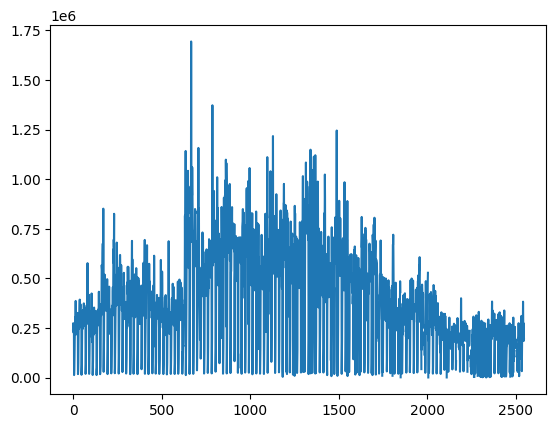

In [ ]:
#Visualisation of Data
oil['Volume'].plot(kind='line')

<Axes: ylabel='Density'>

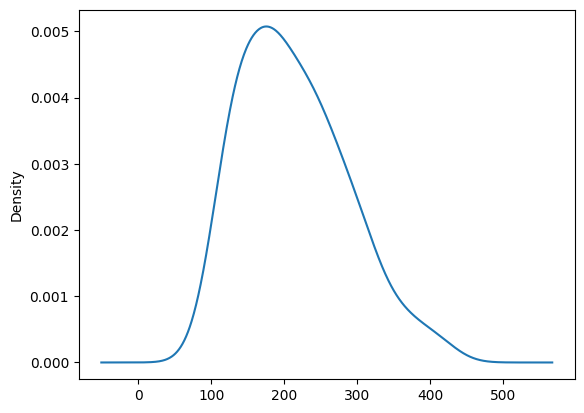

In [ ]:
airline['Passengers'].plot(kind='kde')

<Axes: >

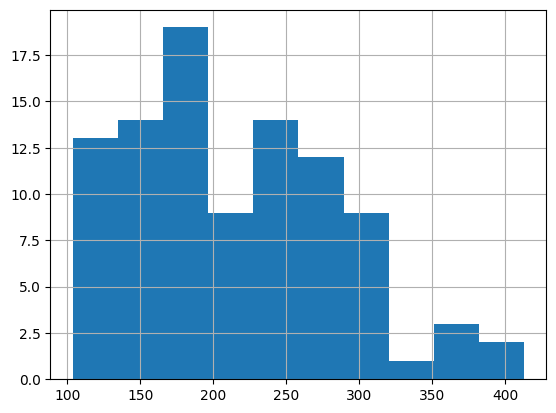

In [ ]:
airline['Passengers'].hist()

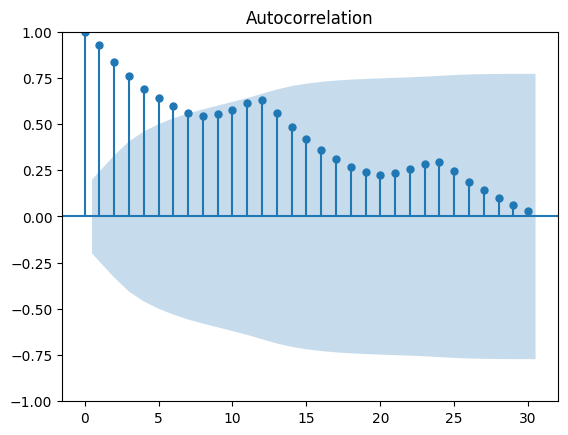

In [ ]:
plot_acf(airline['Passengers'],lags=30)
plt.show()

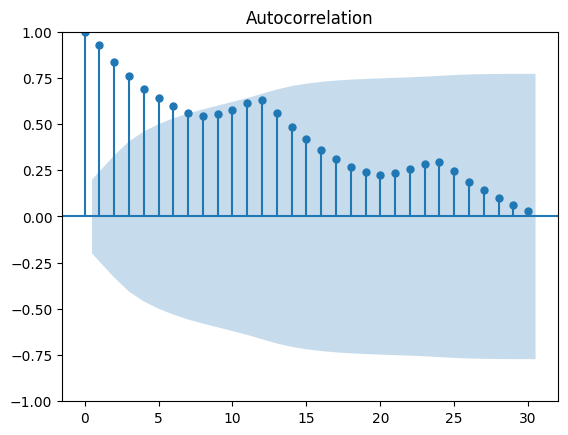

In [ ]:
plot_acf(airline['Passengers'],lags=30)
plt.show()

**Resampling of Data**

In [ ]:
airline.set_index(['Month'],inplace=True)

In [ ]:
#Upsample data to days
upsample= airline.resample('D').mean()

<ipython-input-10-d0b8413c1d7a>:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  upsample= airline.resample('D').mean()


In [ ]:
# Interpolate to fill NAN values
interpolated = upsample.interpolate(method='linear')
print(interpolated.head(32))

            Passengers
Month                 
1995-01-01  112.000000
1995-01-02  112.193548
1995-01-03  112.387097
1995-01-04  112.580645
1995-01-05  112.774194
1995-01-06  112.967742
1995-01-07  113.161290
1995-01-08  113.354839
1995-01-09  113.548387
1995-01-10  113.741935
1995-01-11  113.935484
1995-01-12  114.129032
1995-01-13  114.322581
1995-01-14  114.516129
1995-01-15  114.709677
1995-01-16  114.903226
1995-01-17  115.096774
1995-01-18  115.290323
1995-01-19  115.483871
1995-01-20  115.677419
1995-01-21  115.870968
1995-01-22  116.064516
1995-01-23  116.258065
1995-01-24  116.451613
1995-01-25  116.645161
1995-01-26  116.838710
1995-01-27  117.032258
1995-01-28  117.225806
1995-01-29  117.419355
1995-01-30  117.612903
1995-01-31  117.806452
1995-02-01  118.000000


In [ ]:
data_up=interpolated.reset_index()

**EDA to add date,month,t values, tsquare values, log transform on interpolated data**

In [ ]:
data_up["Date"]=pd.to_datetime(data_up.Month,format="%b-%y")
data_up["Months"]=data_up.Date.dt.strftime("%b")
data_up["Year"]=data_up.Date.dt.strftime("%Y")
data_up

,Month,Passengers,Date,Months,Year
0,1995-01-01,112.000000,1995-01-01,Jan,1995
1,1995-01-02,112.193548,1995-01-02,Jan,1995
2,1995-01-03,112.387097,1995-01-03,Jan,1995
3,1995-01-04,112.580645,1995-01-04,Jan,1995
4,1995-01-05,112.774194,1995-01-05,Jan,1995
...,...,...,...,...,...
2887,2002-11-27,301.333333,2002-11-27,Nov,2002
2888,2002-11-28,302.500000,2002-11-28,Nov,2002
2889,2002-11-29,303.666667,2002-11-29,Nov,2002
2890,2002-11-30,304.833333,2002-11-30,Nov,2002


In [ ]:
data_up['t']= np.arange(1,2893)
data_up['t-square']= data_up['t']**2
data_up['log_transform']=np.log(data_up['Passengers'])
data_up

,Month,Passengers,Date,Months,Year,t,t-square,log_transform
0,1995-01-01,112.000000,1995-01-01,Jan,1995,1,1,4.718499
1,1995-01-02,112.193548,1995-01-02,Jan,1995,2,4,4.720225
2,1995-01-03,112.387097,1995-01-03,Jan,1995,3,9,4.721949
3,1995-01-04,112.580645,1995-01-04,Jan,1995,4,16,4.723670
4,1995-01-05,112.774194,1995-01-05,Jan,1995,5,25,4.725388
...,...,...,...,...,...,...,...,...
2887,2002-11-27,301.333333,2002-11-27,Nov,2002,2888,8340544,5.708217
2888,2002-11-28,302.500000,2002-11-28,Nov,2002,2889,8346321,5.712081
2889,2002-11-29,303.666667,2002-11-29,Nov,2002,2890,8352100,5.715931
2890,2002-11-30,304.833333,2002-11-30,Nov,2002,2891,8357881,5.719765


In [ ]:
dummies=pd.DataFrame(pd.get_dummies(data_up['Months']))
data_up = pd.concat([data_up,dummies],axis = 1)

In [ ]:
pd.set_option('Display.max_rows',3000)

In [ ]:
data_up.head()

,Month,Passengers,Date,Months,Year,t,t-square,log_transform,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
0,1995-01-01,112.000000,1995-01-01,Jan,1995,1,1,4.718499,0,0,0,0,1,0,0,0,0,0,0,0
1,1995-01-02,112.193548,1995-01-02,Jan,1995,2,4,4.720225,0,0,0,0,1,0,0,0,0,0,0,0
2,1995-01-03,112.387097,1995-01-03,Jan,1995,3,9,4.721949,0,0,0,0,1,0,0,0,0,0,0,0
3,1995-01-04,112.580645,1995-01-04,Jan,1995,4,16,4.723670,0,0,0,0,1,0,0,0,0,0,0,0
4,1995-01-05,112.774194,1995-01-05,Jan,1995,5,25,4.725388,0,0,0,0,1,0,0,0,0,0,0,0


In [ ]:
data=data_up.drop(['Month','Months','Year'],axis=1)

In [ ]:
data.head()

,Passengers,Date,t,t-square,log_transform,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
0,112.000000,1995-01-01,1,1,4.718499,0,0,0,0,1,0,0,0,0,0,0,0
1,112.193548,1995-01-02,2,4,4.720225,0,0,0,0,1,0,0,0,0,0,0,0
2,112.387097,1995-01-03,3,9,4.721949,0,0,0,0,1,0,0,0,0,0,0,0
3,112.580645,1995-01-04,4,16,4.723670,0,0,0,0,1,0,0,0,0,0,0,0
4,112.774194,1995-01-05,5,25,4.725388,0,0,0,0,1,0,0,0,0,0,0,0


In [ ]:
#Spliting Data into test and train
train=data.head(2170)
test=data.tail(722)

In [ ]:
train.head()

,Passengers,Date,t,t-square,log_transform,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
0,112.000000,1995-01-01,1,1,4.718499,0,0,0,0,1,0,0,0,0,0,0,0
1,112.193548,1995-01-02,2,4,4.720225,0,0,0,0,1,0,0,0,0,0,0,0
2,112.387097,1995-01-03,3,9,4.721949,0,0,0,0,1,0,0,0,0,0,0,0
3,112.580645,1995-01-04,4,16,4.723670,0,0,0,0,1,0,0,0,0,0,0,0
4,112.774194,1995-01-05,5,25,4.725388,0,0,0,0,1,0,0,0,0,0,0,0


In [ ]:
test.head()

,Passengers,Date,t,t-square,log_transform,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
2170,232.774194,2000-12-10,2171,4713241,5.450069,0,0,1,0,0,0,0,0,0,0,0,0
2171,233.193548,2000-12-11,2172,4717584,5.451869,0,0,1,0,0,0,0,0,0,0,0,0
2172,233.612903,2000-12-12,2173,4721929,5.453665,0,0,1,0,0,0,0,0,0,0,0,0
2173,234.032258,2000-12-13,2174,4726276,5.455459,0,0,1,0,0,0,0,0,0,0,0,0
2174,234.451613,2000-12-14,2175,4730625,5.457249,0,0,1,0,0,0,0,0,0,0,0,0


In [ ]:
import statsmodels.formula.api as smf
from statsmodels.tsa.arima_model import ARIMA
from sklearn.metrics import mean_squared_error

In [ ]:
# Linear
linear_model= smf.ols('Passengers~t',data=train).fit()
linear_pred= pd.Series(linear_model.predict(test['t']))
linear_rmse =np.sqrt(mean_squared_error(np.array(test['Passengers']),np.array(linear_pred)))
linear_rmse

50.17741391799506

In [ ]:
# Exponential
exp_model  =smf.ols("log_transform~t",data=train).fit()
exp_pred =pd.Series(exp_model.predict(test['t']))
exp_rmse =np.sqrt(mean_squared_error(np.array(test['Passengers']),np.array(exp_pred)))
exp_rmse

303.62155944522556

In [ ]:
# Quadratic
quad_model =smf.ols("Passengers~t+t-square",data=train).fit()
quad_pred = pd.Series(quad_model.predict(test[['t','t-square']]))
quad_rmse =np.sqrt(mean_squared_error(np.array(test['Passengers']),np.array(quad_pred)))
quad_rmse

50.17741391799506

In [ ]:
# Addative Seasonality and Quadratic
model_1= smf.ols("Passengers~t+t-square+Apr+Aug+Dec+Feb+Jan+Jul+Jun+Mar+May+Nov+Oct+Sep",data=train).fit()
model_1_pred= pd.Series(model_1.predict(test[['t','t-square','Apr','Aug','Dec','Feb','Jan','Jul','Jun','Mar','May','Nov','Oct','Sep']]))
model_1_rmse=np.sqrt(mean_squared_error(np.array(test['Passengers']),np.array(model_1_pred)))
model_1_rmse

36.59483201891579

In [ ]:
# Multiplicative Seasonality
Mul_sea = smf.ols('log_transform~Apr+Aug+Dec+Feb+Jan+Jul+Jun+Mar+May+Nov+Oct+Sep',data = train).fit()
pred_Mult_sea = pd.Series(Mul_sea.predict(test[['Apr','Aug','Dec','Feb','Jan','Jul','Jun','Mar','May','Nov','Oct','Sep']]))
rmse_Mult_sea = np.sqrt(np.mean((np.array(test['Passengers'])-np.array(np.exp(pred_Mult_sea)))**2))
rmse_Mult_sea

131.57489062147124

In [ ]:
import pandas as pd
from pandas import read_csv
data1 = data[["Date", "Passengers"]]
data1.to_csv("data2.csv", index=False)
series = read_csv("data2.csv", index_col=0)
series.head()

,Passengers
Date,
1995-01-01,112.000000
1995-01-02,112.193548
1995-01-03,112.387097
1995-01-04,112.580645
1995-01-05,112.774194


In [ ]:
from statsmodels.tsa.stattools import adfuller
test_result=adfuller(series['Passengers'])

In [ ]:
def adfuller_test(Passengers):
    result=adfuller(Passengers)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [ ]:
#For ARIMA model we will use grid seach to find the best values of p and q
A=train['Passengers'].values

In [ ]:
def evaluate_arima_model(X, arima_order):
# prepare training dataset
    X = X.astype('float32')
    train_size = int(len(X) * 0.50)
    train, test = X[0:train_size], X[train_size:]
    history = [x for x in train]
# make predictions
    predictions = list()
    for t in range(len(test)):
        model = ARIMA(history, order=arima_order)
# model_fit = model.fit(disp=0)
        model_fit = model.fit(disp=0)
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(test[t])
# calculate out of sample error
    rmse = sqrt(mean_squared_error(test, predictions))
    return rmse

In [ ]:
def evaluate_models(dataset, p_values, d_values, q_values):
    dataset = dataset.astype('float32')
    best_score, best_cfg = float('inf'), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p,d,q)
                try:
                    rmse = evaluate_arima_model(A, order)
                    if rmse < best_score:
                        best_score, best_cfg = rmse, order
                    print('ARIMA%s RMSE=%.3f' % (order,rmse))
                except:
                    continue
    print('Best ARIMA%s RMSE=%.3f' % (best_cfg, best_score))


In [ ]:
# evaluate parameters
p_values = range(0, 2)
d_values = range(0, 2)
q_values = range(0, 2)
warnings.filterwarnings("ignore")
evaluate_models(A, p_values, d_values, q_values)

Best ARIMANone RMSE=inf


In [ ]:
table=[['Linear Model',linear_rmse],['Exponential Model',exp_rmse],['Quadratic Model',quad_rmse],['Addative Seasonality and Quadratic',model_1_rmse],['Multiplicative Seasonality',rmse_Mult_sea],['ARIMA',0.173]]
table_up=pd.DataFrame(table,columns=['Model','rmse']).sort_values('rmse')
table_up

,Model,rmse
5,ARIMA,0.173000
3,Addative Seasonality and Quadratic,36.594832
0,Linear Model,50.177414
2,Quadratic Model,50.177414
4,Multiplicative Seasonality,131.574891
1,Exponential Model,303.621559


**From all the Models ARIMA has the lowest RMSE value
Hence fiting the Arima model on data
First we shall fit it on train and then on test and train together**

In [ ]:
B=train['Passengers'].values
B=B.astype('float32')

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(B, order=(1,0,0))
model_fit = model.fit()

In [ ]:
import statsmodels
statsmodels.__version__

!pip install statsmodels

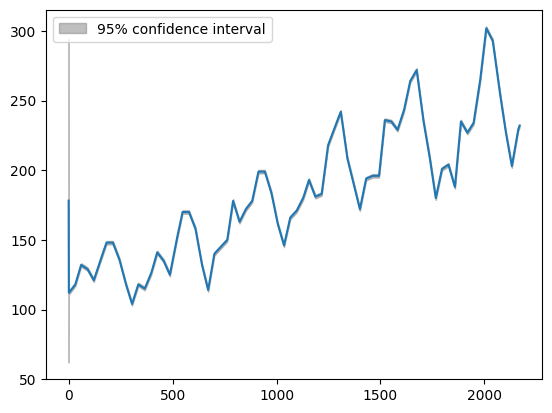

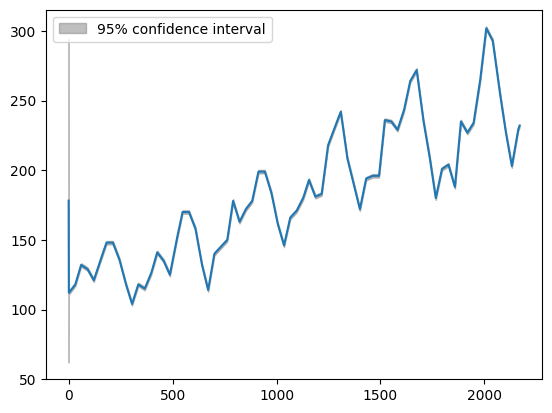

In [ ]:
from statsmodels.graphics.tsaplots import plot_predict
plot_predict(model_fit)

**Fitting the model on both test and train together**

In [ ]:
C= data['Passengers'].values
C=C.astype('float32')

In [ ]:
model_final=ARIMA(C,order=(1,1,1))
model_final_fit=model_final.fit()

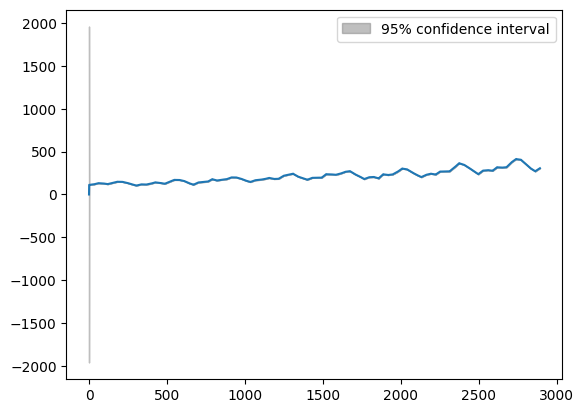

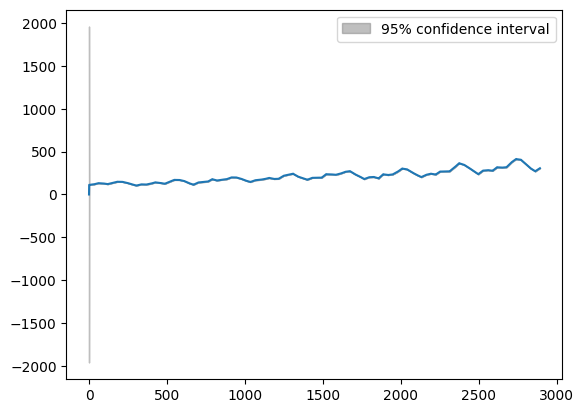

In [ ]:
forecast_1=model_final_fit.forecast(steps=100)[0]
plot_predict(model_final_fit)

In [ ]:
forecast_1

307.13789277607935